# Demo

A demostration script for the ECLYPSE network simulator extension.

This script validates the implementation of the M/M/1 queuing model,
physical link parameters, and routing tables by simulating a "bottleneck"
scenario.
It sets up a topology (Sensor → Gateway → Cloud), defines traffic flows,
and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [13]:
import time
from eclypse.remote.service import Service
from mm1_infrastructure import MM1Infrastructure
from network_application import NetworkAwareApplication
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

**DemoService** is a placeholder service to represent application endpoints (e.g. Sensors, Cloud).

In this network-focused simulation, services do not perform internal computation (CPU/RAM logic). They serve as anchors in the application graph to define the source and destination of network flows.

In [14]:
class DemoService(Service):
    def __init__(self, name):
        super().__init__(name)
        self.step_callback = None

    async def step(self):
        pass

The following script orchestrates the bottleneck simulation scenario.

Steps performed:
1. **Infrastructure setup**: Creates a 3-node network (Sensor, Gateway, Cloud). Configures a fast LAN link (100 mbps) and a slow WAN link (10 Mbps) to create a bottleneck.
2. **Application setup**: Defines an application with a flow from Sensor to Cloud.
3. **Routing**: Simulates OSPF convergence to populate routing tables.
4. **Simulation**: Sends a burst of packets and tracks their travel time hop-by-hop.
5. **Analysis**: Prints a table showing start times, arrival times, and queuing delays.

**The Supply: Service Time (The Speed Limit)**
First, we look at the physical limitations of the "Bottleneck" link.
- **The Constraints**: The link is limited to **10 Mbps** (10 million bits per second). Each packet you send is a fixed size of 1500 Bytes (which is $1500 \times 8 = 12000$ bits).
- **The Calculation**: To push one single packet onto the wire, the router requires a specific amount of time.

$Time = \frac{12000 \: bits}{10000000 \: bits/sec} = 0.0012 \: seconds = 1.2 \: ms$

- **The Reality**: This means that once the Gateway starts transmitting a packet, it is physically "busy" for the next **1,2 ms**. It cannot touch another packet during this window.

**The Demand: Arrival Rate (The Traffic Jam)**
Next, we look at how aggressively your application is creating work.
- **The input**: the `inter_arrival_time` is configured to **0.0005** seconds (0.5 ms).
- **The Rate**: This implies you are effectively trying to push data at a rate of 24 Mbps (12000 bits/0.0005 s).
- **The Conflict**: You are asking the router to do a job every 0.5 ms, but the router takes 1.2 ms to finish that job.

**The Consequences: Accumulating "Debt"**
This mismatch creates a guaranteed growing backlog. It's like a sink filling up faster than it can drain.
- **The Deficit**: for every single packet that arrives, the router falls further behind.

$Deficit \, per \, packet = Service \, Time (1.2 \, ms) - Arrival \, time (0.5 \,  ms) = 0.7 \, ms$
- **The Prediction**: Every time a new packet arrives, it will have to wait **0.7 ms longer** than the packet before it. This isn't random noise; it is a structural, linear accumulation of delay.

**Theoretical Calculation for the 50th Packet**
Based on this linear accumulation model, we can estimate the **Queuing Delay ($W_q$) for the N-th packet. The 50th packet ($N = 50$) finds 49 packet ahead of it that have contributed to the creation of the queue.

$W_{q,50} \approx (N-1) \times Deficit$

$W_{q,50} \approx 49 \times 0.7 \: ms = 34.3 \: ms$

To this waiting delay, we must add its own service time (1.2 ms) and propagation delay (negligible in this context), bringing the theoretical Total Delay ($T_{tot}) to:

$T_{tot,50} = W_{q,50} + T_s \approx 34.3 + 1.2 = 35.5 \: ms$


In [17]:
print("[Setup] Simulation configuration...")
infra = MM1Infrastructure("DemoNet")
infra.add_node("Sensor")
infra.add_node("Gateway")
infra.add_node("Cloud")
infra.add_physical_link("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)
infra.add_physical_link("Gateway", "Cloud", bandwidth_mbps=10, length_km=50) # Bottleneck

# Add services to the application
app = NetworkAwareApplication("IoT_Video_Stream")
app.add_service(DemoService("Sensor"))
app.add_service(DemoService("Cloud"))

# STRESS TEST PARAMETERS
PACKET_SIZE = 1500       # 1500 Bytes
PACKETS_TO_SEND = 50     # 50 Packets

app.add_flow("Sensor", "Cloud", packet_size_bytes=PACKET_SIZE, packets_per_tick=PACKETS_TO_SEND)
print(f"    Configured flow: {PACKETS_TO_SEND} packets of {PACKET_SIZE} Byte")
print("\n Routing table setup (OSPF Simulation)")
infra.install_shortest_path_routes()

next_hop = infra.get_next_hop("Sensor", "Cloud")
print(f"    Check Routing Table: Sensor -> Cloud passes through '{next_hop}'? {'Yes' if next_hop == 'Gateway' else 'No'}")

# -------------------------------------------------------------------------
# Running the simulation with data collection
# -------------------------------------------------------------------------

# UPDATE: Extremely aggressive input rate
inter_arrival_time = 0.0005 # 0.5 ms


print(f"\n Starting burst transmission of {PACKETS_TO_SEND} packets...")
sim_data = []
base_time = 0.0

for i in range(1, PACKETS_TO_SEND + 1):
    send_time = base_time + (i * inter_arrival_time)

    # Run simulation
    result = infra.simulate_packet_routing("Sensor", "Cloud", PACKET_SIZE, send_time)

    # Safe calculations
    total_delay_ms = result['total_e2e_delay'] * 1000
    
    # Safe arrival calculation
    arrival_time = send_time + result['total_e2e_delay']

    gateway_queue_ms = 0.0
    for hop in result['hops']:
        if "Gateway->Cloud" in hop['hop']:
            gateway_queue_ms = hop['queue'] * 1000

    sim_data.append({
        "Packet_ID": i,
        "Start_Time_s": send_time,
        "Arrival_Time_s": arrival_time,
        "Total_Delay_ms": total_delay_ms,
        "Gateway_Queue_ms": gateway_queue_ms
    })

# --- DATAFRAME & ANALYSIS ---
df = pd.DataFrame(sim_data)

print("\n[5] Data Preview:")
df

[Setup] Simulation configuration...
Add edge flow Sensor->Cloud: 50 pkt/tick with packet size 1500 Bytes
    Configured flow: 50 packets of 1500 Byte

 Routing table setup (OSPF Simulation)
--- Configuration of Routing Tables (OSPF simulation) ---
Routing tables installed on all nodes.
    Check Routing Table: Sensor -> Cloud passes through 'Gateway'? Yes

 Starting burst transmission of 50 packets...

[5] Data Preview:


,Packet_ID,Start_Time_s,Arrival_Time_s,Total_Delay_ms,Gateway_Queue_ms
0,1,0.0005,0.002287,1.787042,0.000000
1,2,0.0010,0.003211,2.210999,0.894667
2,3,0.0015,0.004440,2.940191,1.418754
3,4,0.0020,0.005125,3.124808,2.170997
4,5,0.0025,0.008815,6.314952,2.297252
5,6,0.0030,0.009182,6.181787,5.309597
6,7,0.0035,0.009418,5.917956,5.343468
7,8,0.0040,0.011871,7.871018,4.870447
8,9,0.0045,0.013094,8.593503,7.073483
9,10,0.0050,0.013293,8.292541,7.725826


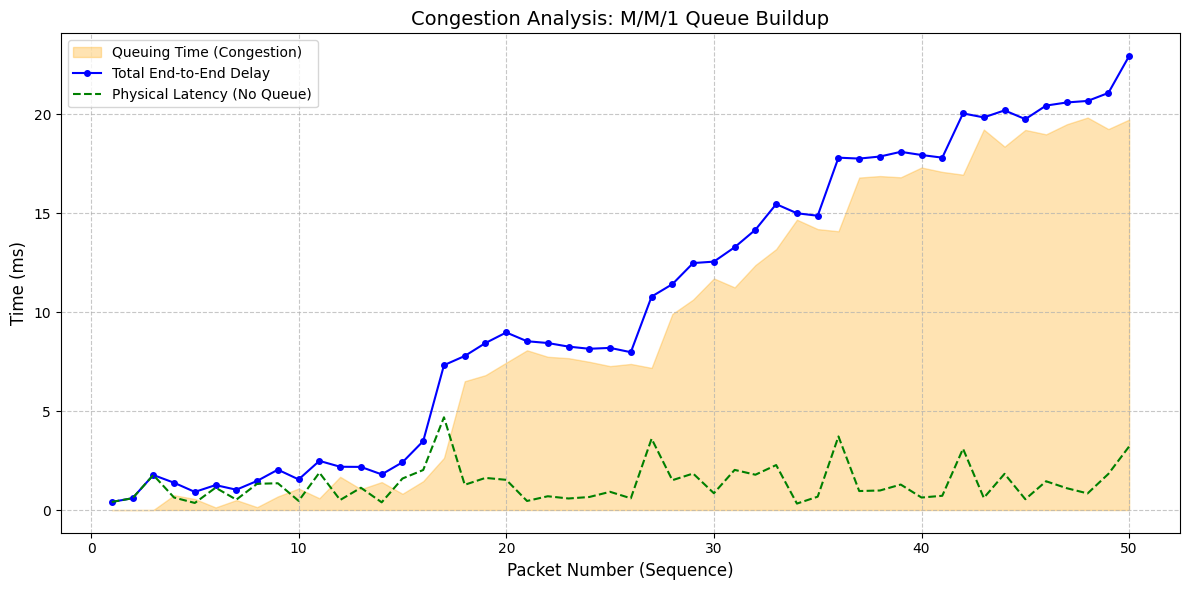

In [16]:
# --- PLOTTING ---
plt.figure(figsize=(12, 6))

# Queue area (filled to highlight the impact of congestion)
plt.fill_between(df["Packet_ID"], df["Gateway_Queue_ms"], color="orange", alpha=0.3, label="Queuing Time (Congestion)")

# Total delay line
plt.plot(df["Packet_ID"], df["Total_Delay_ms"], label="Total End-to-End Delay", color="blue", marker='o', markersize=4)

# Theoretical line (transmission + propagation only, without queue)
# This helps visualize how much the queue contributes to the total delay
physical_delay = df["Total_Delay_ms"] - df["Gateway_Queue_ms"]
plt.plot(df["Packet_ID"], physical_delay, label="Physical Latency (No Queue)", color="green", linestyle="--")

# Titles and Labels
plt.title("Congestion Analysis: M/M/1 Queue Buildup", fontsize=14)
plt.xlabel("Packet Number (Sequence)", fontsize=12)
plt.ylabel("Time (ms)", fontsize=12)

# Grid and Legend
plt.legend(loc="upper left")
plt.grid(True, which='both', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**Conclusion**

The theoretical calculation predicts that, in the absence of stochastic variability, the 50th packet should suffer a delay of approximately 35.5 ms, dominated almost entirely by queuing time (>96% of the total). This value serves as a baseline to evaluate the simulation: deviations from this number (such as the ~25 ms observed in the graph) are attributable and expected due to the probabilistic nature (M/M/1) of the simulated service times, which in specific runs may result faster on average than the nominal value.